In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Load specific forecasting tools
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tools.eval_measures import rmse

# Ignore harmless warnings
import warnings
warnings.filterwarnings("ignore")

# Database & data manipulation
import duckdb
from sqlalchemy import (
    create_engine
)
import os
from dotenv import load_dotenv

In [46]:
conn = duckdb.connect()

# DuckDB connection to PostgreSQL
conn.execute("INSTALL postgres")
conn.execute("LOAD postgres")

# Attach to PostgreSQL database directly
conn.execute(f"""
    ATTACH '
            host={os.getenv("POSTGRES_HOST")} 
            port={os.getenv("POSTGRES_PORT", 5432)} 
            dbname={os.getenv("POSTGRES_DB")}
            user={os.getenv("POSTGRES_USER")}
            password={os.getenv("POSTGRES_PASSWORD")}
            '
    AS pg (TYPE postgres)
""")

In [47]:
drill_set_rel = conn.sql("SELECT * FROM pg.silver.v_ml_drilling_set")

In [48]:
drill_set_rel.describe()

┌─────────┬────────────┬───────────────────┬────────────────────┬─────────┬───────────────────┬───────────────────┬─────────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬─────────────────────┬───────────────────┬───────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬─────────────────────┬─────────────────────┬────────────────────┬───────────────────┬────────────────────┬────────────────────┬───────────────────┬────────────────────┬───────────────────┬────────────────────┬────────────────────┬────────────────────┬───────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬────────────────────┬─────────────────────┬─────────────────────┬───────────────────┬────────────────────┬───────────────────┬────────────────────┬─────────────────────┬────────────────────┬────────────────────┬─────────────────────┬────────────────────┬───

<Axes: title={'center': 'Check for missing data'}>

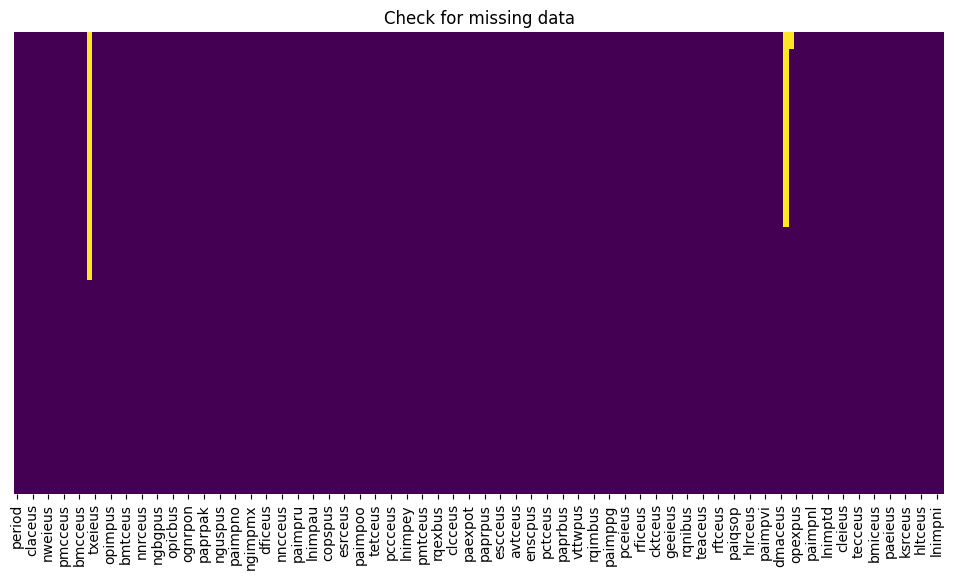

In [49]:
# Check for missing data

fig = plt.figure(figsize=(12,6)) # Setting `plt` obj global size to (12 x 6)
ax = plt.axes()
ax.set_title("Check for missing data")
sns.heatmap(
    drill_set_rel.df().isnull(),
    yticklabels=False,
    cbar=False,
    cmap='viridis',
    ax=ax
    )

In [50]:
test_df = drill_set_rel.df()
test_df['period'] = pd.to_datetime(test_df['period'])
test_df = test_df.set_index('period')
test_df = test_df.sort_index()

In [51]:
# testing
print("Type: ", type(test_df.index))
print(f"""Date Range:
Minimum: {test_df.index.min()}
Maximum: {test_df.index.max()}
""")

Type:  <class 'pandas.DatetimeIndex'>
Date Range:
Minimum: 2000-01-01 00:00:00
Maximum: 2025-12-01 00:00:00



## Oil Variables Feature Engineering

* Get count of remedial rigs aka rigs that are not for oil or gas.
* Merge monthly data columns with weekly data columns to increase data density
* Re-scale Oil Storage, merge data from Oil Storage features
* Interporlate features
* Drop extra features   

### Feature Group: Rig Count

In [70]:
# # Find all the 'Crude Oil Rotary Rig' series
# coil_rig_cols = " + ".join(list(conn.sql("""
#     SELECT 
#         msn
#         ,series_description
#     FROM pg.silver.v_total_energy_series
#     WHERE series_description LIKE '%Crude Oil Rotary Rig%'
# """).df()['msn']))
# print(coil_rig_cols)

PANRPUS


In [71]:
# # Find all the 'Natural Gas Rotary Rig' series
# ngas_rig_cols = " + ".join(list(conn.sql("""
#     SELECT 
#         msn
#         ,series_description
#     FROM pg.silver.v_total_energy_series
#     WHERE series_description LIKE '%Natural Gas Rotary Rig%'
#         AND series_description NOT LIKE '%Oil%'
# """).df()['msn']))
# print(ngas_rig_cols)

NGNRPUS


In [59]:
# # Find all the 'Rig' series
# total_rig_cols = " + ".join(list(conn.sql("""
#     SELECT 
#         msn
#         ,series_description
#     FROM pg.silver.v_total_energy_series
#     WHERE series_description LIKE '%Crude Oil and Natural Gas Rotary Rig%'
#         AND series_description NOT LIKE '%Trajectory%'
# """).df()['msn']))
# print(total_rig_cols)

OGVTPUS + OGNRPOF + OGHRPUS + OGNRPON + OGDRPUS + OGNRPUS


In [88]:
monthly_avg_rel = conn.sql(f"""
    SELECT
        period
        ,COALESCE(PANRPUS, 0)   AS oilrig_count
        ,COALESCE(NGNRPUS, 0)   AS gasrig_count
        ,COALESCE(OGNRPON, 0)   AS onshorerig_count
        ,COALESCE(OGNRPOF, 0)   AS offshorerig_count
        ,COALESCE(OGNRPUS, 0)   AS totalrig_count
    FROM drill_set_rel
""")

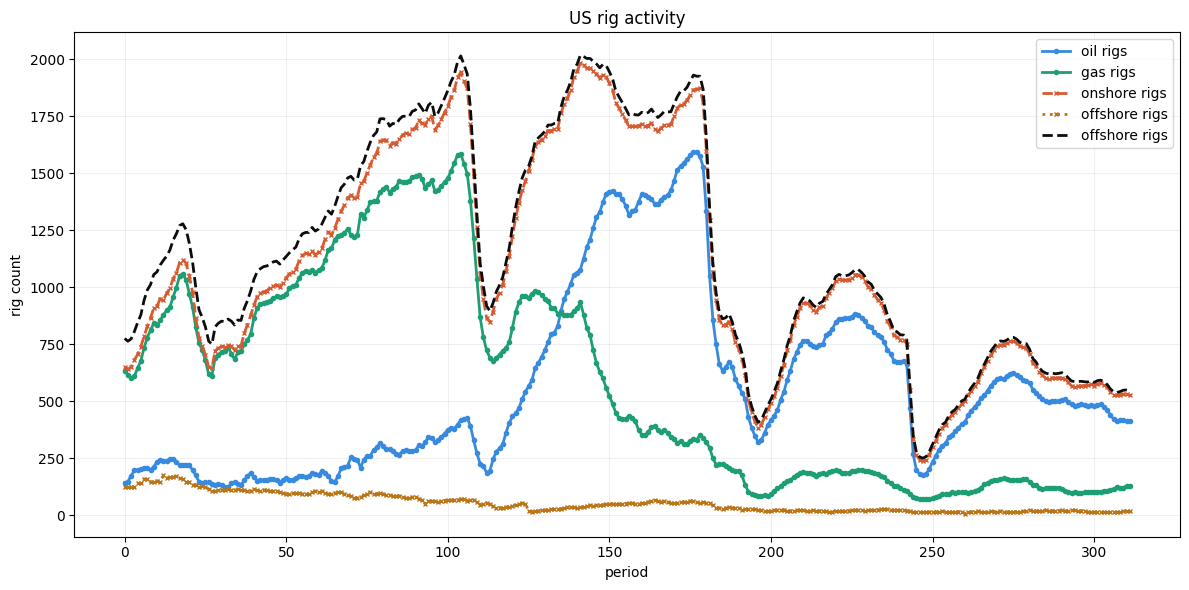

In [85]:
monthly_avg_df = monthly_avg_rel.df()

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(monthly_avg_df.index, monthly_avg_df['oilrig_count'],
        color='#378ADD', marker='o', markersize=3,
        linewidth=2, label='oil rigs')

ax.plot(monthly_avg_df.index, monthly_avg_df['gasrig_count'],
        color='#1D9E75', marker='o', markersize=3,
        linewidth=2, label='gas rigs')

ax.plot(monthly_avg_df.index, monthly_avg_df['onshorerig_count'],
        color='#D85A30', marker='x', markersize=3,
        linewidth=2, linestyle='--', label='onshore rigs')

ax.plot(monthly_avg_df.index, monthly_avg_df['offshorerig_count'],
        color='#BA7517', marker='x', markersize=3,
        linewidth=2, linestyle=':', label='offshore rigs')

ax.plot(monthly_avg_df.index, monthly_avg_df['totalrig_count'],
        color="#0C0C0C", markersize=3,
        linewidth=2, linestyle='--', label='offshore rigs')


ax.set_title('US rig activity')
ax.set_xlabel('period')
ax.set_ylabel('rig count')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [91]:
monthly_avg_rel_rem = conn.sql(f"""
    SELECT
        period
        ,oilrig_count
        ,gasrig_count
        ,onshorerig_count
        ,offshorerig_count
        ,totalrig_count - (oilrig_count + gasrig_count)     AS remrig_count 
        ,totalrig_count
    FROM monthly_avg_rel
""")
monthly_avg_rel_rem

┌────────────┬──────────────┬──────────────┬──────────────────┬───────────────────┬──────────────┬────────────────┐
│   period   │ oilrig_count │ gasrig_count │ onshorerig_count │ offshorerig_count │ remrig_count │ totalrig_count │
│    date    │    double    │    double    │      double      │      double       │    double    │     double     │
├────────────┼──────────────┼──────────────┼──────────────────┼───────────────────┼──────────────┼────────────────┤
│ 2000-01-01 │        143.0 │        632.0 │            650.0 │             125.0 │          0.0 │          775.0 │
│ 2000-02-01 │        147.0 │        616.0 │            641.0 │             122.0 │          0.0 │          763.0 │
│ 2000-03-01 │        173.0 │        600.0 │            649.0 │             124.0 │          0.0 │          773.0 │
│ 2000-04-01 │        196.0 │        609.0 │            680.0 │             125.0 │          0.0 │          805.0 │
│ 2000-05-01 │        199.0 │        645.0 │            705.0 │         

### Feature Group: Imports and Exports

In [135]:
# # Find all the 'Petroleum Imports' series
total_import_cols = ", ".join(list(conn.sql("""
    SELECT 
        msn
    FROM pg.silver.v_total_energy_series
    WHERE series_description LIKE '%Petroleum Imports%'
        AND series_description LIKE '%Thousand Barrels%'
    	AND series_description NOT LIKE '%Total%'
""").df()['msn']))
print(total_import_cols)

PAIMPNO, PAIMPBZ, PAIMPUK, PAIMPVI, PAIMPPG, PAIMPOT, PAIMPKU, PAIMPNL, PAIMPUA, PAIMPNI, PAIMPSA, PAIMPCN, PAIMPIQ, PAIMPLY, PAIMPOO, PAIMPVE, PAIMPCL, PAIMPEN, PAIMPAG, PAIMPRU, PAIMPMX


In [136]:
# # Find all the 'Petroleum Exports' series
total_export_cols = ", ".join(list(conn.sql("""
    SELECT 
        msn
    FROM pg.silver.v_total_energy_series
    WHERE series_description LIKE '%Petroleum Exports%'
        AND series_description LIKE '%Thousand Barrels%'
    	AND series_description NOT LIKE '%Total%'
""").df()['msn']))
print(total_export_cols)

PAEXPSK, PAEXPCH, PAEXPNL, PAEXPIH, PAEXPOT, PAEXPJA, PAEXPMX, PAEXPCN, PAEXPSN, PAEXPUK, PAEXPBZ


In [137]:
import_export = conn.sql(f"""
    SELECT
        {total_import_cols}
        ,{total_export_cols}
    FROM drill_set_rel
""")

In [138]:
import_export.df().columns

Index(['paimpno', 'paimpbz', 'paimpuk', 'paimpvi', 'paimppg', 'paimpot',
       'paimpku', 'paimpnl', 'paimpua', 'paimpni', 'paimpsa', 'paimpcn',
       'paimpiq', 'paimply', 'paimpoo', 'paimpve', 'paimpcl', 'paimpen',
       'paimpag', 'paimpru', 'paimpmx', 'paexpsk', 'paexpch', 'paexpnl',
       'paexpih', 'paexpot', 'paexpja', 'paexpmx', 'paexpcn', 'paexpsn',
       'paexpuk', 'paexpbz'],
      dtype='str')

In [139]:
def split_and_trim_str(cols: str) -> list:
    return [x.strip() for x in cols.split(",")]

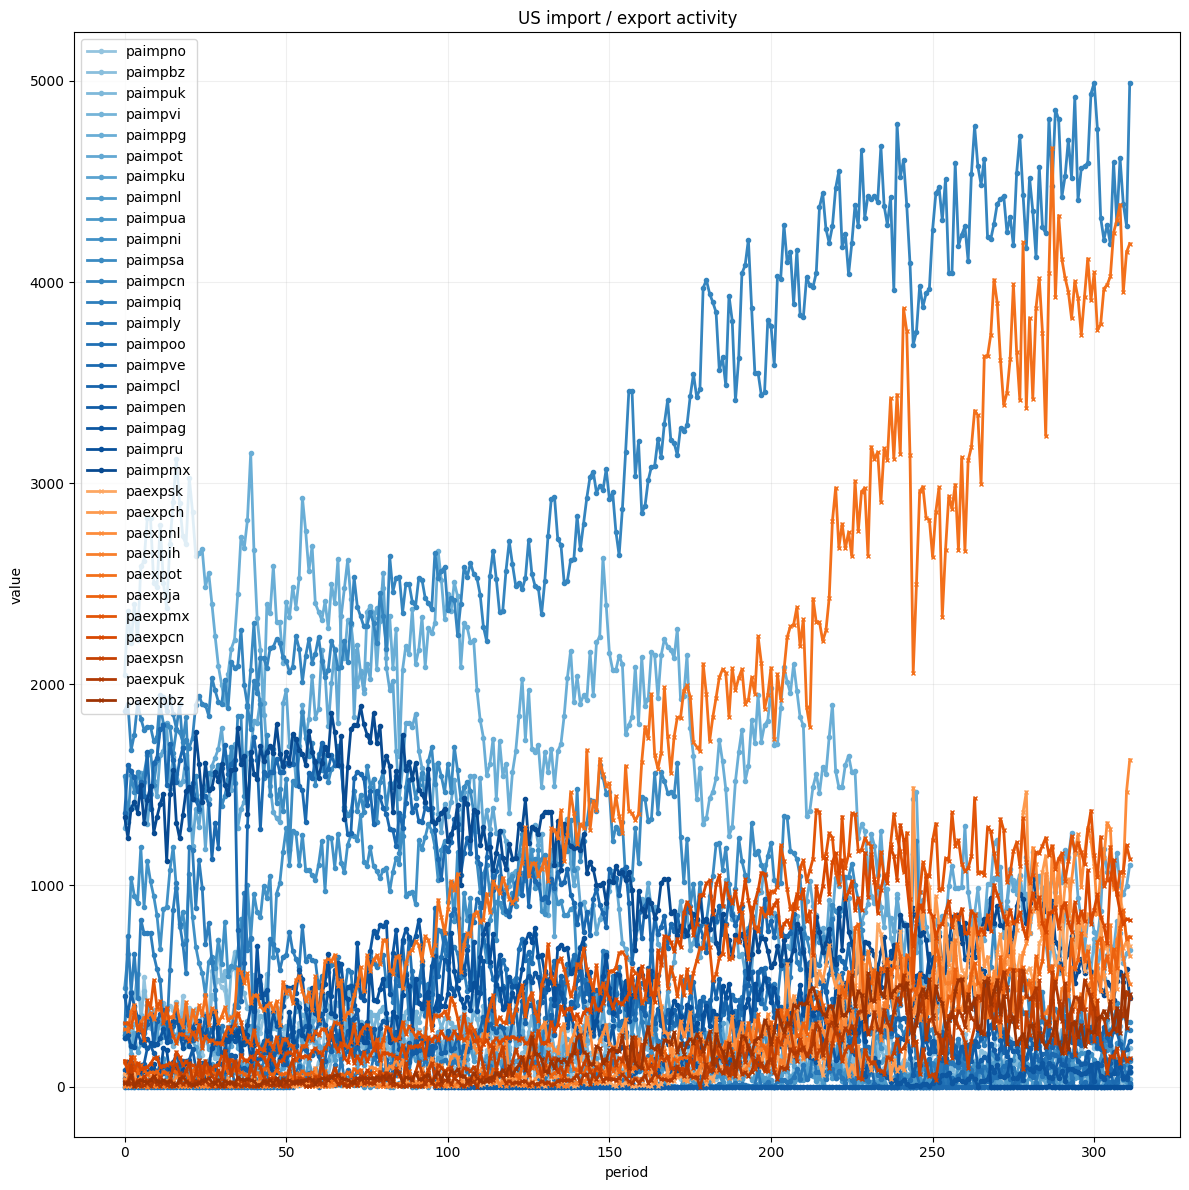

In [140]:
import_cols = [c.lower() for c in split_and_trim_str(total_import_cols)]
export_cols = [c.lower() for c in split_and_trim_str(total_export_cols)]

# Generate distinct colors for each series
import_colors = cm.Blues(np.linspace(0.4, 0.9, len(import_cols)))
export_colors = cm.Oranges(np.linspace(0.4, 0.9, len(export_cols)))

import_export_df = import_export.df()

fig, ax = plt.subplots(figsize=(12, 12))

for col, color in zip(import_cols, import_colors):
    ax.plot(import_export_df.index, import_export_df[col],
            color=color, marker='o', markersize=3,
            linewidth=2, label=col)

for col, color in zip(export_cols, export_colors):
    ax.plot(import_export_df.index, import_export_df[col],
            color=color, marker='x', markersize=3,
            linewidth=2, label=col)

ax.set_title('US import / export activity')
ax.set_xlabel('period')
ax.set_ylabel('value')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

## Selecting Features

In [ ]:
# Features from antoniodagnino

# --- Oil Features ---
# - Oil price:                              oil_price.sql
# - Oil rig count:                          oil_rigs.sql
# - Gas rig count:                          gas_rigs.sql
# - Oil well count:                         oil_wells.sql
# - Oil storage:                            v_total_energy_crude_inv         
# - Oil days of supply **not found**        
# - US Population                           
# - US Emissions
# - REM Rig Count
# - Oil Imports
# - Oil Exports
# - Oil consumption
# - Oil Production

# --- Gas Features ---
# - Gas Price
# - Gas rig count
# - Onshore Count
# - Offshore count
# - Gas well Count
# - Gas imports amount
# - Gas exports amount
# - Gas production amount
# - Gas consumption amount
# - Gas storage amount